# 04 Convolution, Filtering, and Matched Filters

## Purpose

This notebook turns Fourier intuition back into time-domain operations. The goal is to understand how linear time-invariant systems act on sampled signals, why convolution is the natural operation for filtering, how correlation differs from convolution, and why matched filters are so important in sonar and radar.

## Prerequisites

- Notebook 01: Signals, Systems, and Sampling
- Notebook 02: Sinusoids, Complex Exponentials, and Phase
- Notebook 03: Fourier Transform and Spectral Intuition
- Basic comfort with sampled sequences and spectra

## Learning Objectives

By the end of this notebook, you should be able to:

- explain what an impulse response means,
- interpret convolution as a sliding weighted sum,
- describe why low-pass filtering smooths fast variation,
- distinguish convolution from correlation,
- explain what a matched filter is doing geometrically,
- and connect matched-filter peaks to delay estimation and later pulse-compression ideas.


## New Terms In This Notebook

- **Linear time-invariant (LTI) system**: a system whose response scales linearly with the input and does not change when the input is shifted in time.
- **Impulse response**: the output of a system when the input is a unit impulse. For an LTI system, it fully characterizes the system.
- **Convolution**: the operation that combines an input sequence with an impulse response to produce the output of an LTI system.
- **Kernel**: the short weighting sequence used in convolution. In filtering problems, the kernel is the impulse response.
- **Low-pass filter**: a filter that preserves slower variation and attenuates faster variation.
- **Correlation**: a similarity measure between one sequence and a shifted reference sequence.
- **Matched filter**: a filter built from the time-reversed conjugate of a known reference waveform. It produces a strong output when the received data contains that waveform.
- **Complex conjugate**: for a complex number or sequence, conjugation flips the sign of the imaginary part. In real-valued examples, conjugation does nothing.
- **Delay estimate**: an estimate of when a reference waveform appears in the data, often taken from the peak of a correlation or matched-filter output.


## Big Picture

Notebook 03 asked which frequencies are present in the data. This notebook asks a different question: what happens when a system acts on the data?

For LTI systems, convolution is the time-domain rule. The same operation explains smoothing filters, pulse shaping, and the matched filters that later help us detect echoes and estimate delay. The important point is not just that convolution is a formula. It is a reusable mental model for how a system combines nearby samples.


## Mathematical Definitions and Relevant Intuition

### Convolution For An LTI System

For a discrete-time linear time-invariant (LTI) system with input $x[n]$, impulse response $h[n]$, and output $y[n]$, the convolution sum is

$$
y[n] = (x * h)[n] = \sum_{m=-\infty}^{\infty} x[m] \, h[n-m].
$$

This equation says that the output at sample $n$ is built by collecting contributions from many input samples. The term $h[n-m]$ shifts a flipped copy of the impulse response across the input, and the sum adds all overlapping contributions.

### Why Convolution Has This Form

The intuition is that an LTI system responds to each input impulse in the same way, just shifted in time. A general input sequence can be viewed as a weighted sum of shifted impulses, so the total output is the sum of shifted and scaled copies of the impulse response. Convolution is the bookkeeping rule that performs that sum.

So convolution is not just an arbitrary formula. It is the mathematical statement of a simple idea: **each input sample launches a scaled copy of the impulse response, and the output is the sum of all those copies.**

### Correlation As A Similarity Test

For two discrete sequences $x[n]$ and $r[n]$, one common cross-correlation form is

$$
(x \star r)[n] = \sum_{m=-\infty}^{\infty} x[m] \, r[m+n].
$$

Correlation asks a different question from convolution. Instead of asking how a system transforms an input, it asks how similar one sequence is to a shifted copy of a reference sequence. Large correlation means the local shapes line up well at that shift.

### Matched Filter

For a known reference waveform $s[n]$, the matched-filter impulse response is

$$
h_{MF}[n] = s^*[-n],
$$

where the $^*$ symbol means complex conjugation. In the real-valued examples used here, conjugation does nothing, so this becomes simple time reversal. The matched-filter output is therefore a correlation-like operation: it becomes large when the received data aligns with the known waveform.

This is why matched filtering is useful for detection and delay estimation. It turns waveform alignment into a peak that we can measure.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from _bootstrap import bootstrap_src_path

bootstrap_src_path()

from sonar_py_lib.dsp import correlate, linear_convolve, matched_filter, normalize, sine_wave, time_axis
from sonar_py_lib.notebook_utils import set_plot_style
from sonar_py_lib.plotting import make_figure, plot_signal

set_plot_style()


def stem_like(ax, values, *, title: str, xlabel: str = "Sample index", ylabel: str = "Amplitude", color: str = "C0", label: str | None = None) -> None:
    idx = np.arange(len(values))
    ax.axhline(0.0, color="0.65", linewidth=1.0)
    ax.vlines(idx, 0.0, values, color=color, linewidth=2.0, alpha=0.9)
    ax.scatter(idx, values, color=color, s=36, zorder=3, label=label)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)


def normalized_db(values: np.ndarray, *, floor_db: float = -80.0) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    peak = np.max(np.abs(values))
    if peak <= 0.0:
        return np.full_like(values, floor_db, dtype=float)
    return 20.0 * np.log10(np.maximum(np.abs(values) / peak, 10.0 ** (floor_db / 20.0)))


## Assumptions

- We use small synthetic examples so the effect of each operation is easy to see.
- We focus on one-dimensional discrete-time sequences.
- We mostly emphasize intuition and geometry rather than the most general proofs.
- We use real-valued examples first, even though the same ideas extend naturally to complex baseband signals.


## Impulse Response And Convolution

An LTI system is completely described by its impulse response. Once we know that short sequence, convolution tells us the output for any input.

A useful mental model is this: at each output sample, we place a flipped copy of the kernel over the input, multiply overlapping samples, and add them. That sliding weighted sum is convolution.

For the first figure we use the finite sequences x[n] = [0, 1, 2, 1, 0] and h[n] = [0.25, 0.5, 0.25].

The purpose of the figure is to show that convolution is not an abstract symbol: each output sample is built from a local weighted sum of nearby input samples.

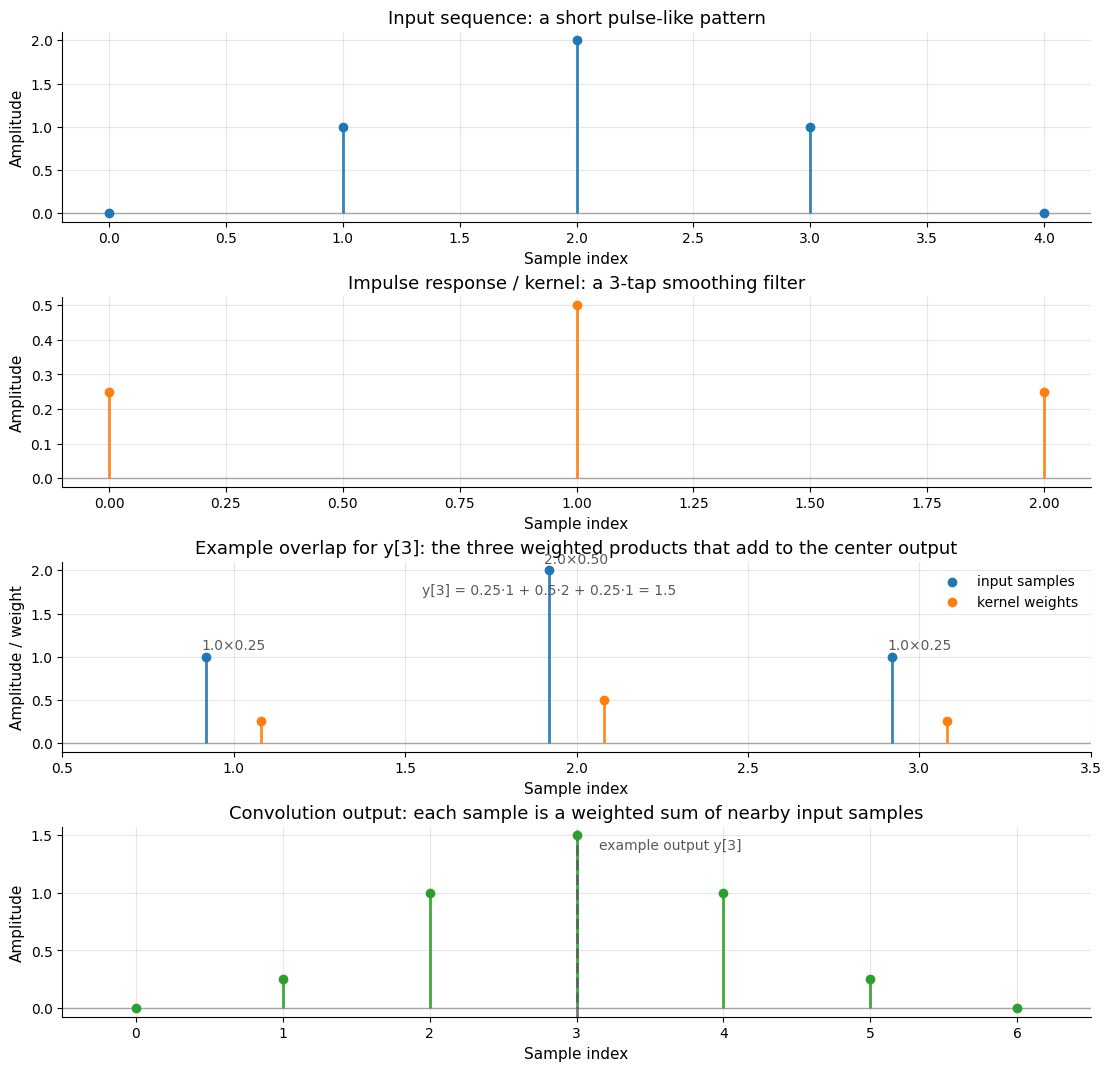

In [2]:
x = np.array([0.0, 1.0, 2.0, 1.0, 0.0])
h = np.array([0.25, 0.5, 0.25])
y_full = linear_convolve(x, h, mode="full")

overlap_idx = np.array([1, 2, 3])
overlap_vals = x[overlap_idx]
kernel_vals = h
example_y = float(np.dot(overlap_vals, kernel_vals))

fig, axes = make_figure(nrows=4, ncols=1, figsize=(11.0, 10.6), sharex=False)
stem_like(axes[0], x, title="Input sequence: a short pulse-like pattern", color="C0")
stem_like(axes[1], h, title="Impulse response / kernel: a 3-tap smoothing filter", color="C1")

axes[2].axhline(0.0, color="0.65", linewidth=1.0)
axes[2].vlines(overlap_idx - 0.08, 0.0, overlap_vals, color="C0", linewidth=2.0, alpha=0.9)
axes[2].scatter(overlap_idx - 0.08, overlap_vals, color="C0", s=36, zorder=3, label="input samples")
axes[2].vlines(overlap_idx + 0.08, 0.0, kernel_vals, color="C1", linewidth=2.0, alpha=0.9)
axes[2].scatter(overlap_idx + 0.08, kernel_vals, color="C1", s=36, zorder=3, label="kernel weights")
axes[2].set_title("Example overlap for y[3]: the three weighted products that add to the center output")
axes[2].set_xlabel("Sample index")
axes[2].set_ylabel("Amplitude / weight")
axes[2].set_xlim(0.5, 3.5)
axes[2].legend(loc="upper right")
for idx, xv, hv in zip(overlap_idx, overlap_vals, kernel_vals):
    axes[2].text(idx, max(xv, hv) + 0.08, f"{xv:.1f}×{hv:.2f}", ha="center", color="0.35", fontsize=10)
axes[2].text(1.55, 1.72, f"y[3] = 0.25·1 + 0.5·2 + 0.25·1 = {example_y:.1f}", color="0.35")

stem_like(axes[3], y_full, title="Convolution output: each sample is a weighted sum of nearby input samples", color="C2")
axes[3].axvline(3, color="0.35", linestyle="--", alpha=0.8)
axes[3].text(3.15, 0.92 * np.max(y_full), "example output y[3]", color="0.35")
axes[3].set_xlim(-0.5, len(y_full) - 0.5)
plt.show()

The output is wider than the input because the filter spreads each input sample across several neighboring output locations. The center of the pulse is preserved, but the sharp corners are softened because the kernel averages nearby values together.

The extra overlap panel is the key teaching step: it shows one specific convolution sample in detail. The three overlapping input values are multiplied by the three kernel weights, and those products add to form the highlighted center output. Every other output sample is built by the same sliding weighted-sum rule, just with the overlap shifted to a different position.

## Low-Pass Filtering Smooths Fast Variation

A moving-average style kernel is a simple low-pass filter. It suppresses rapid sample-to-sample change while preserving slower trends.

The example below combines a slow sinusoid with a faster ripple. After filtering, the fast ripple is reduced much more than the slow component.

In the example below, with sample rate fs = 128 Hz, the input is x[n] = 0.9 sin(2π·3 n / fs) + 0.35 sin(2π·18 n / fs), and the averaging kernel is h[n] = (1/7)[1,1,1,1,1,1,1].

The purpose of the figure is to show that convolution with a short averaging kernel suppresses the faster ripple much more than the slower oscillation.

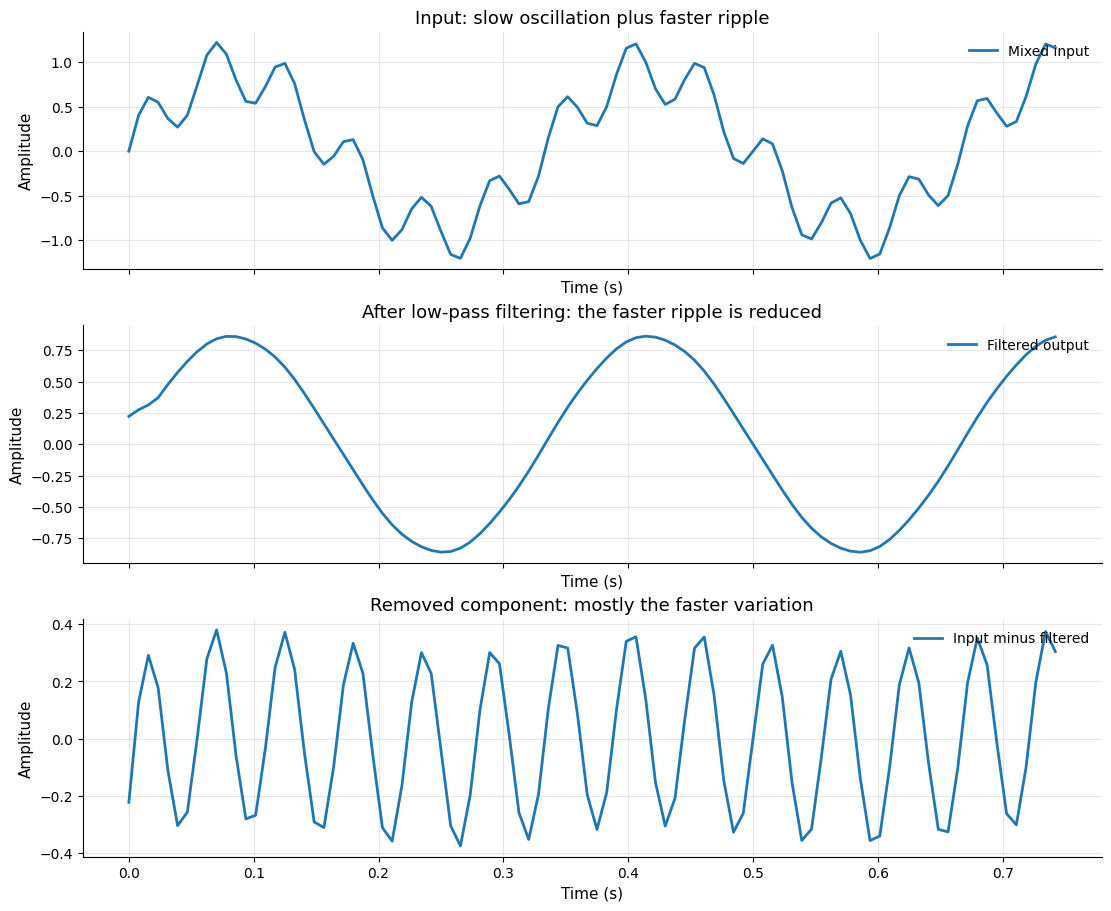

In [3]:
fs = 128.0
duration_s = 1.0
t = time_axis(int(fs * duration_s), fs)
x_slow = 0.9 * np.sin(2.0 * np.pi * 3.0 * t)
x_fast = 0.35 * np.sin(2.0 * np.pi * 18.0 * t)
x_mixed = x_slow + x_fast

h_lp = np.ones(7, dtype=float) / 7.0
y_lp = linear_convolve(x_mixed, h_lp, mode="same")

fig, axes = make_figure(nrows=3, ncols=1, figsize=(11.0, 9.0), sharex=True)
plot_signal(t[:96], x_mixed[:96], ax=axes[0], title="Input: slow oscillation plus faster ripple", xlabel="Time (s)", ylabel="Amplitude", label="Mixed input")
axes[0].legend(loc="upper right")
plot_signal(t[:96], y_lp[:96], ax=axes[1], title="After low-pass filtering: the faster ripple is reduced", xlabel="Time (s)", ylabel="Amplitude", label="Filtered output")
axes[1].legend(loc="upper right")
plot_signal(t[:96], x_mixed[:96] - y_lp[:96], ax=axes[2], title="Removed component: mostly the faster variation", xlabel="Time (s)", ylabel="Amplitude", label="Input minus filtered")
axes[2].legend(loc="upper right")
plt.show()


This is the same idea we saw spectrally in Notebook 03. Smoother kernels in time correspond to stronger emphasis on low-frequency behavior and reduced response to rapid fluctuation.


## Convolution Versus Correlation

Convolution flips the kernel before sliding it across the input. Correlation does not. That distinction disappears for symmetric kernels, but it matters for asymmetric reference waveforms.

The example below uses an intentionally asymmetric template so the difference is easy to see. The purpose of the figure is to show that the correlation peak occurs at the lag where the reference aligns with the received data, while the convolution output does not have that same direct alignment meaning because of the flip.

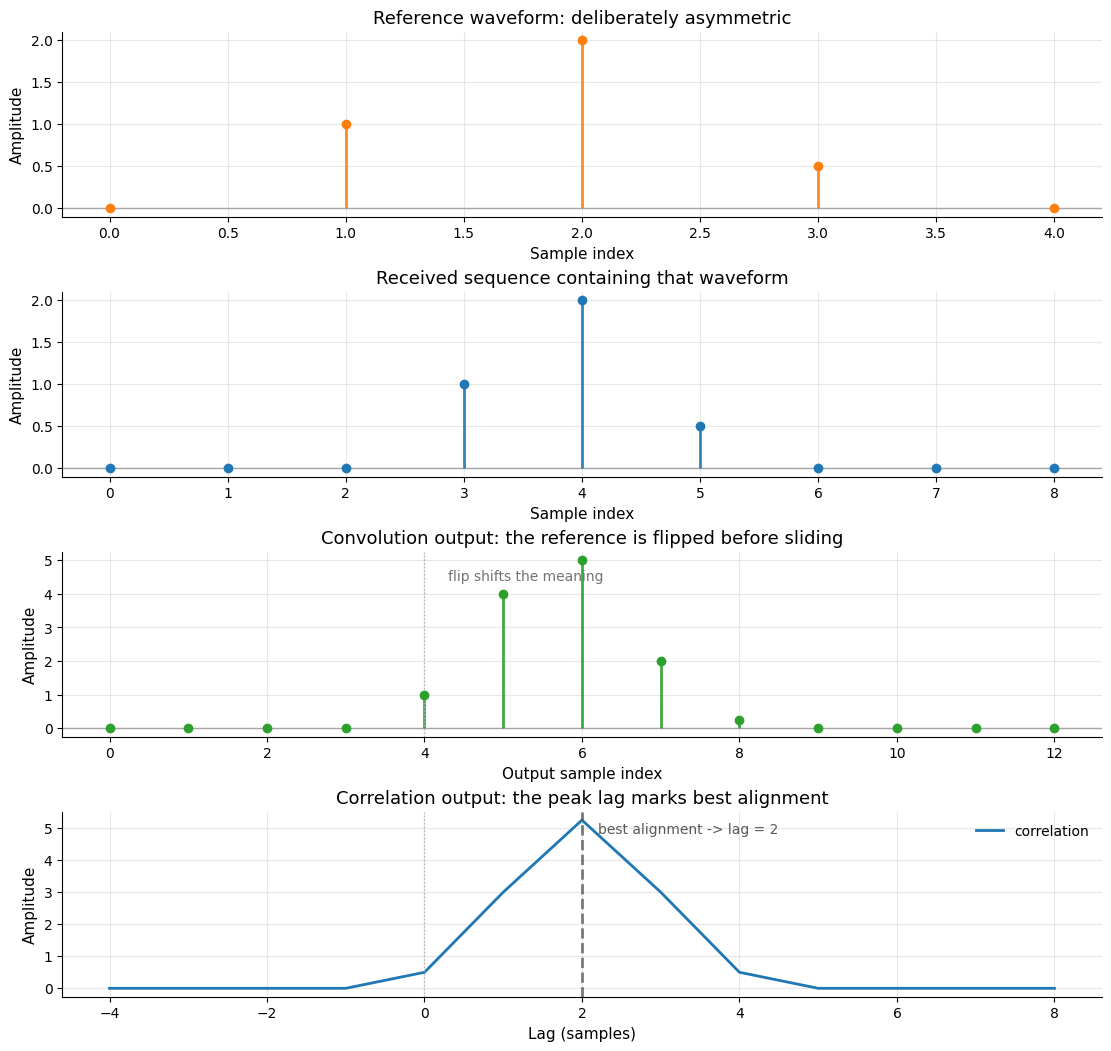

In [4]:
reference = np.array([0.0, 1.0, 2.0, 0.5, 0.0])
received = np.array([0.0, 0.0, 0.0, 1.0, 2.0, 0.5, 0.0, 0.0, 0.0])

conv_out = linear_convolve(received, reference, mode="full")
corr_out = correlate(received, reference, mode="full")
corr_lags = np.arange(-(len(reference) - 1), len(received))
peak_corr = int(np.argmax(np.abs(corr_out)))
peak_lag = int(corr_lags[peak_corr])

fig, axes = make_figure(nrows=4, ncols=1, figsize=(11.0, 10.4), sharex=False)
stem_like(axes[0], reference, title="Reference waveform: deliberately asymmetric", color="C1")
stem_like(axes[1], received, title="Received sequence containing that waveform", color="C0")
stem_like(axes[2], conv_out, title="Convolution output: the reference is flipped before sliding", color="C2")
axes[2].set_xlabel("Output sample index")
axes[2].axvline(len(reference) - 1, color="0.7", linestyle=":", linewidth=1.0)
axes[2].text(len(reference) - 0.7, 0.88 * np.max(conv_out), "flip shifts the meaning", color="0.45")
plot_signal(corr_lags, corr_out, ax=axes[3], title="Correlation output: the peak lag marks best alignment", xlabel="Lag (samples)", ylabel="Amplitude", label="correlation")
axes[3].axvline(0, color="0.7", linestyle=":", linewidth=1.0)
axes[3].axvline(peak_lag, color="0.35", linestyle="--", alpha=0.8)
axes[3].text(peak_lag + 0.2, 0.92 * np.max(np.abs(corr_out)), f"best alignment -> lag = {peak_lag}", color="0.35")
axes[3].legend(loc="upper right")
plt.show()

Correlation is the better language when the question is "where does this known pattern appear in the data?" That is exactly the question behind delay estimation and echo detection.

In this figure, the correlation peak occurs at the lag where the asymmetric reference waveform best lines up with the received sequence. That is why the horizontal axis for the correlation plot should be read as an alignment shift, not just an output sample number.

## Matched Filtering Finds A Known Pulse In Noise

A matched filter is built from a known reference waveform. In the real-valued examples here, it is just the time-reversed reference. When the received data contains that waveform, the matched-filter output adds the aligned samples coherently and produces a strong peak.

This is the core detection idea behind later ranging and pulse-compression notebooks.


In the example below, a known pulse is inserted into noisy data, and the figure is meant to show that matched filtering converts waveform alignment into a measurable peak location.

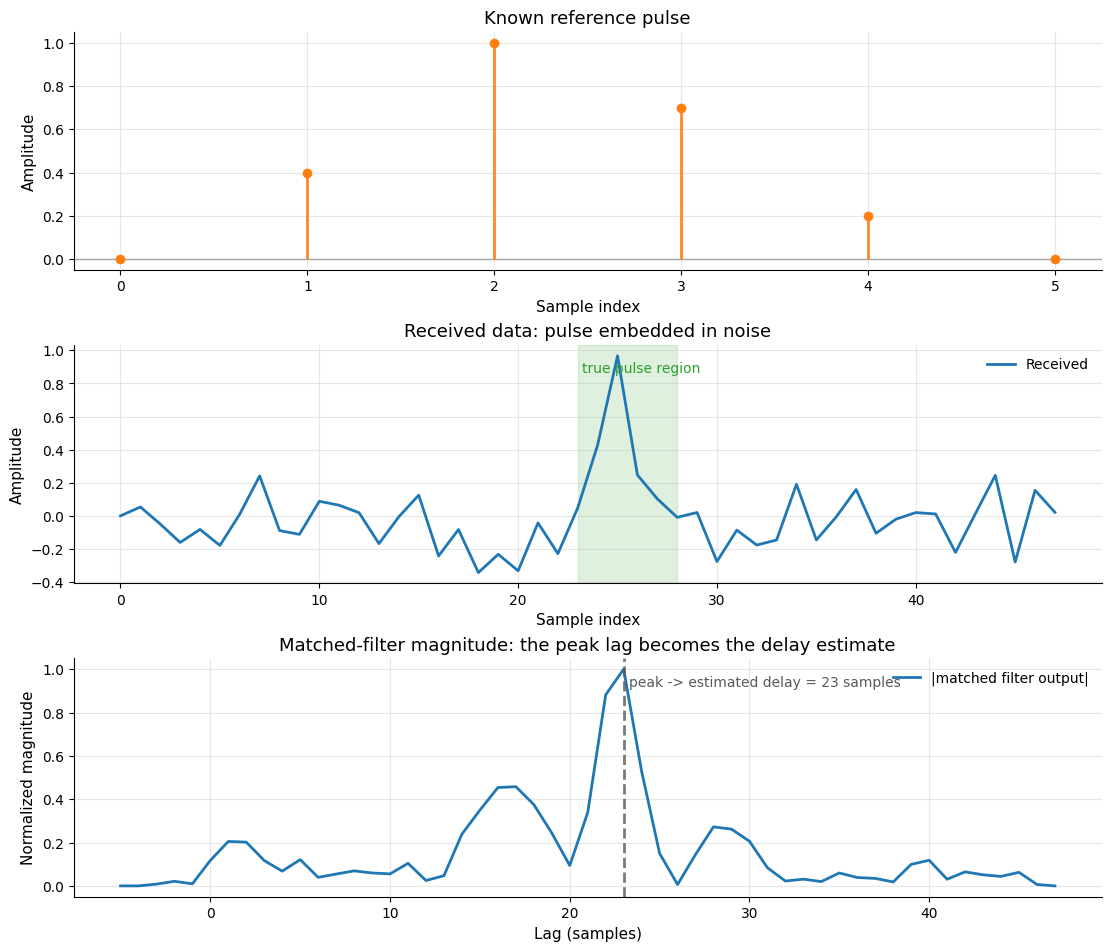

True insertion index: 23 samples
Estimated delay from matched-filter peak: 23 samples


In [5]:
rng = np.random.default_rng(7)
reference_pulse = np.array([0.0, 0.4, 1.0, 0.7, 0.2, 0.0])
received_noise = 0.18 * rng.normal(size=48)
insert_at = 23
received_pulse = received_noise.copy()
received_pulse[insert_at : insert_at + len(reference_pulse)] += reference_pulse

mf_out = matched_filter(received_pulse, reference_pulse, mode="full")
mf_lags = np.arange(-(len(reference_pulse) - 1), len(received_pulse))
peak_index = int(np.argmax(np.abs(mf_out)))
delay_est = int(mf_lags[peak_index])

fig, axes = make_figure(nrows=3, ncols=1, figsize=(11.0, 9.4), sharex=False)
stem_like(axes[0], reference_pulse, title="Known reference pulse", color="C1")
plot_signal(np.arange(len(received_pulse)), received_pulse, ax=axes[1], title="Received data: pulse embedded in noise", xlabel="Sample index", ylabel="Amplitude", label="Received")
axes[1].axvspan(insert_at, insert_at + len(reference_pulse) - 1, color="C2", alpha=0.15)
axes[1].text(insert_at + 0.2, 0.9 * np.max(received_pulse), "true pulse region", color="C2")
plot_signal(mf_lags, normalize(np.abs(mf_out)), ax=axes[2], title="Matched-filter magnitude: the peak lag becomes the delay estimate", xlabel="Lag (samples)", ylabel="Normalized magnitude", label="|matched filter output|")
axes[2].axvline(delay_est, color="0.35", linestyle="--", alpha=0.8)
axes[2].text(delay_est + 0.3, 0.92, f"peak -> estimated delay = {delay_est} samples", color="0.35")
axes[2].legend(loc="upper right")
plt.show()

print(f"True insertion index: {insert_at} samples")
print(f"Estimated delay from matched-filter peak: {delay_est} samples")

The matched-filter output is not magic. It is a weighted accumulation. When the reference lines up with the embedded pulse, many products have the same sign and reinforce one another. Away from alignment, the products do not add coherently, so the output stays smaller.

In this real-valued example, the matched filter and correlation produce their peak at the same lag. Because the horizontal axis is already expressed as lag, the peak location can be read directly as the delay estimate.

## Tradeoffs And Limitations

Several practical tradeoffs are visible here:

- Smoothing filters reduce fast variation, but they also blur sharp transitions.
- Correlation is useful for finding known patterns, but it depends on having a good reference.
- Matched filtering creates strong peaks when the assumed waveform is correct, but mismatch in shape, timing, or phase reduces that gain.
- Real systems often care about causal implementation, finite precision, and computational cost, none of which these small examples emphasize.

This notebook also leaves out several important realities:

- colored noise rather than simple white noise,
- Doppler shifts that distort the reference waveform,
- complex-valued baseband pulse models,
- and FFT-based fast convolution for long sequences.


## Recap

- The impulse response tells us how an LTI system acts on any input.
- Convolution is the sliding weighted sum that produces the output of that system.
- Low-pass filters smooth rapid variation by averaging nearby samples.
- Correlation measures similarity and is natural for alignment and delay estimation.
- A matched filter is a correlation-like operation that produces a strong peak when a known waveform is present.


## Suggested Next Questions

- How does noise change detection reliability?
- How do false alarms and missed detections trade off against one another?
- How should we estimate signal power or noise power from finite data?

The next notebook turns to noise, detection, and estimation so these filtering ideas can be evaluated under uncertainty.
